# Finance Text Analysis: Predicting Stock Movements from News Headlines

# Introduction

Financial news headlines often have a significant impact on stock prices. Investors and analysts pay close attention to news to gauge market sentiment and potential movements. In this project, the aim is to leverage natural language processing techniques to predict stock market movements from news headlines. This idea is inspired by prior work where daily news headlines over years have been used to predict stock indices. By analyzing the text of headlines, I hope to capture market-relevant signals such as sentiment or key events that influence stock prices. I will perform exploratory data analysis on the textual data, then build predictive models. In particular, I will start with a recurrent neural network for sequence modeling and later fine-tune a BERT transformer model for improved performance. BERT and other transformer-based models have achieved state-of-the-art results in NLP tasks, thanks to their ability to consider context from large corpora and then be fine-tuned for specific tasks.
The rise of such language models has revolutionized text analysis in finance, enabling extraction of insights from news data.

I will perform an exploratory data analysis on the textual data, then build predictive models. I will start with a recurrent neural network for sequence modeling and later fine-tune a BERT transformer model for improved performance. BERT and other transformer-based models have achieved state-of-the-art results in NLP tasks. The rise of such language models has revolutionized text analysis in finance, enabling deeper insights from news data.

Project Roadmap:

    Data Collection & Exploration: I use a dataset of news headlines labeled with next-day stock movement. I will load the data and inspect its structure and class balance.

    Data Preprocessing: I will clean the text to eliminate noise. Then tokenize the headlines and prepare them as sequences for modeling.

    Exploratory Data Analysis: I will examine the data distribution and visualize aspects like word frequencies. I also consider performing sentiment analysis on headlines to check if sentiment correlates with stock moves.

    Modeling with LSTM: I build an embedding + LSTM + Dense neural network to predict stock movement from the headline text. LSTMs are effective for tasks where sequence context is crucial and have been used successfully in similar text classification tasks. I will train the model and consider tuning hyperparameters.

    Fine-Tuning BERT: Next, I fine-tune a pre-trained BERT model on our headline data to leverage transfer learning. BERT’s transformer architecture considers the full context of each word in a sentence, potentially yielding better performance than an LSTM on language understanding tasks. I will use HuggingFace Transformers to load a pre-trained BERT and add a classification layer on top.

    Evaluation: I will evaluate the models on a test set using metrics like accuracy, precision, recall, and a confusion matrix. A confusion matrix provides a breakdown of predicted vs actual classes, which helps identify where the models are making errors.

# Data Loading and Exploration

In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/stocknews/Combined_News_DJIA.csv')
print("Shape of data:", df.shape)
print("Total samples:", len(df))
print(df.head(5))

Shape of data: (1989, 27)
Total samples: 1989
         Date  Label                                               Top1  \
0  2008-08-08      0  b"Georgia 'downs two Russian warplanes' as cou...   
1  2008-08-11      1  b'Why wont America and Nato help us? If they w...   
2  2008-08-12      0  b'Remember that adorable 9-year-old who sang a...   
3  2008-08-13      0  b' U.S. refuses Israel weapons to attack Iran:...   
4  2008-08-14      1  b'All the experts admit that we should legalis...   

                                                Top2  \
0            b'BREAKING: Musharraf to be impeached.'   
1        b'Bush puts foot down on Georgian conflict'   
2                 b"Russia 'ends Georgia operation'"   
3  b"When the president ordered to attack Tskhinv...   
4  b'War in South Osetia - 89 pictures made by a ...   

                                                Top3  \
0  b'Russia Today: Columns of troops roll into So...   
1  b"Jewish Georgian minister: Thanks to Israeli ...  

This dataset contains daily news headlines and a label indicating the Dow Jones Industrial Average movement on that date. Each row corresponds to a trading day from 2008 to 2016. There are 27 columns in total: one for the date, one Label column, and 25 columns Top1, Top2, ..., Top25 which are the day's top news headlines. The label is binary: 1 means the DJIA’s closing price rose or stayed the same, and 0 means it decreased on that day. Running the code above, we see the dataset shape and a preview:

    Shape of data: (1989, 27) – indicating 1,989 days of data with 27 columns per day.

    Total samples: 1989

    The first few rows show the Date, Label, and snippets of the Top1–Top5 headlines for those dates. For example, on 2008-08-08 the label is 0 and Top1 headline is "Georgia 'downs two Russian warplanes' as cou...", etc. The raw headlines in the CSV appear prefixed with b' and contain various characters including quotes and punctuation.

One key aspect to examine is the class balance of the target variable Label. In this dataset, there are 924 days labeled 0 and 1065 days labeled 1, so the classes are slightly imbalanced but fairly close to balanced. This means a baseline model that always predicted the majority class would be correct about 53.5% of the time. I will keep this baseline in mind when evaluating our models.

# Data Preprocessing

Before modeling, I will need to clean and prepare the text data. This involves combining all headlines for each day into a single text and then cleaning that text.

In [3]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_b_prefix(val):
    if isinstance(val, str) and val.startswith("b'"):
        return val[2:-1]  # remove b' and ending '
    if isinstance(val, str) and val.startswith('b"'):
        return val[2:-1]  # remove b" and ending "
    return val  # otherwise, leave as is

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return " ".join(tokens)

headline_columns = [f'Top{i}' for i in range(1, 26)]
for col in headline_columns:
    df[col] = df[col].apply(clean_b_prefix)
df['combined_headline'] = df[headline_columns].apply(lambda x: ' '.join(str(val) for val in x if pd.notnull(val)), axis=1)
df['clean_headline'] = df['combined_headline'].apply(preprocess_text)

print(df[['combined_headline', 'clean_headline']].head(3))



[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                   combined_headline  \
0  Georgia 'downs two Russian warplanes' as count...   
1  Why wont America and Nato help us? If they won...   
2  Remember that adorable 9-year-old who sang at ...   

                                      clean_headline  
0  georgia downs two russian warplanes countries ...  
1  wont america nato help us wont help us help ir...  
2  remember adorable yearold sang opening ceremon...  


I created a new column combined_headline that concatenates all the Top1–Top25 headlines for each day into one long string. This gives a single text per day, which will serve as my input feature for prediction. While concatenating, I ensure we skip any missing values so that the combined text only contains actual headlines.

I then define a function to remove the leading b' or b" prefix that some headlines have. After that, I define a preprocess_text function to normalize the text:

    Convert text to lowercase

    Remove all characters that are not letters or whitespace. This helps eliminate noise such as URLs, special characters, or stock tickers if any.

    Split the text into tokens and remove common English stopwords. Stopwords like "the", "and", "is", etc., carry little informative value about market sentiment and removing them can improve model focus on key words.

Applying this preprocessing, I get a new column clean_headline which contains the cleaned, processed text of all headlines for each day.

By cleaning and combining, I have transformed 25 separate headline columns into one textual feature. This simplifies our data and ensures the model can consider the day's entire news context. I decided not to perform stemming or lemmatization at this stage; however, those could be applied to further normalize word forms. I also have not done any manual correction of semantic nuances. Those will be handled implicitly by the model.

In [4]:
from sklearn.model_selection import train_test_split

X = df['clean_headline'].values
y = df['Label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

max_length = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

print("Padded X_train shape:", X_train_pad.shape)
print("Padded X_test shape:", X_test_pad.shape)


import numpy as np

y_train = np.array(y_train)
y_test = np.array(y_test)


Training samples: 1591
Testing samples: 398


2025-04-28 05:03:31.789773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745816611.980129      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745816612.035970      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Padded X_train shape: (1591, 100)
Padded X_test shape: (398, 100)


# Exploratory Data Analysis 

Now that I have the data prepared, I conduct some EDA to understand the dataset better before modeling.

Each data point is a day’s collection of news headlines and a binary stock movement label. The key questions in EDA for this project are:

    How are the target labels distributed?

    What is the typical length of the combined headlines text? Are there days with unusually high or low amount of news?

    What are the most common words in these headlines? Do we notice any obvious differences in word frequency between days the market went up vs down?

    Could sentiment of the headlines be an indicator of the label?

As noted, there are 1065 days labeled 1 and 924 days labeled 0. This slight imbalance means our models should be evaluated not just on accuracy but also on metrics like precision and recall to ensure I'm capturing both classes well.

The number of words in each day’s clean_headline varies. On average, since there can be up to 25 headlines, the combined text might contain on the order of dozens to a couple hundred words. In practice, after stopword removal, many days have fewer than 100 words. I will see below that we chose a maximum sequence length of 100 for modeling, which seems to cover most days’ headlines. An exceptionally news-heavy day might have slightly more, but by truncating I will sacrifice some detail for consistency in model input length.

An informal examination of the headlines suggests words like "government", "market", "economy", "war", "president", etc., appear frequently given the dataset spans major world and financial events.
This kind of analysis can hint at whether there is a detectable sentiment or topic difference associated with market moves.

Another useful EDA approach is calculating a sentiment score for each day’s news and comparing it across labels.

Since most of the features are textual, traditional correlation plots are not directly applicable. If I derive numerical features such as word count, average sentiment, or count of positive/negative words for each day, I could compute correlations among those and with the label. For instance, I might find a negative correlation between the frequency of words like "loss" or "fear" and the stock movement, meaning those words appear more on down days. Similarly, a positive correlation might exist between the overall sentiment score and the label. Including a correlation heatmap of such derived features could strengthen our analysis, highlighting any linear relationships.

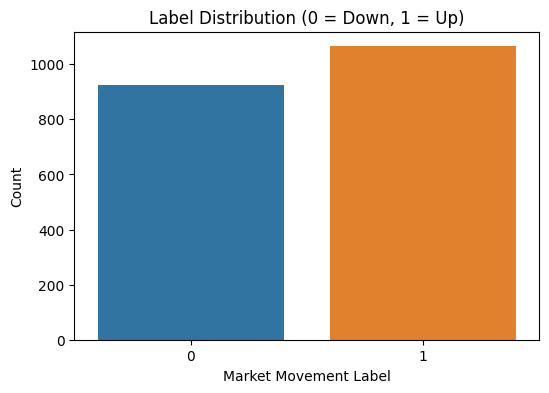

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


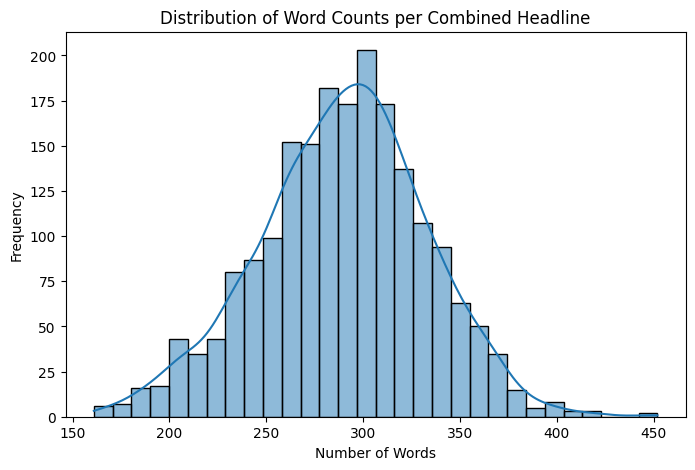

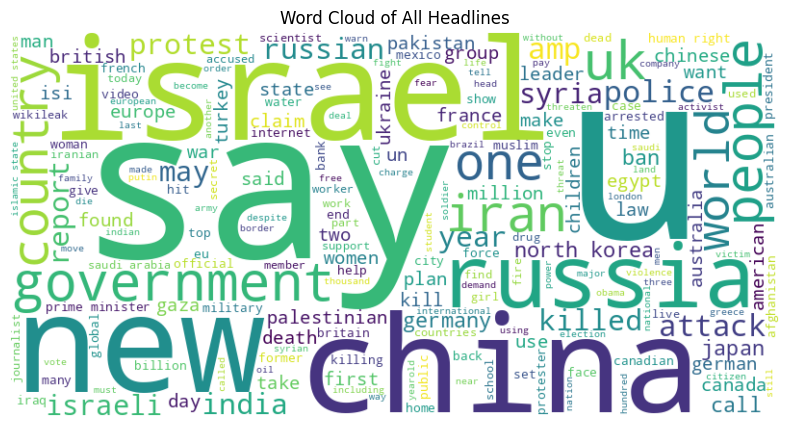

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


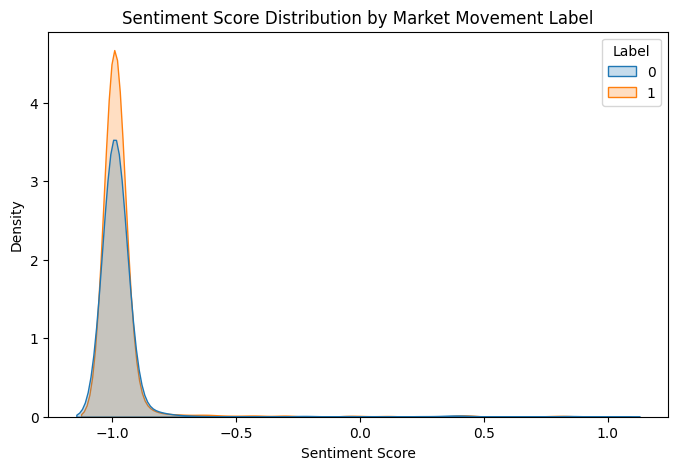

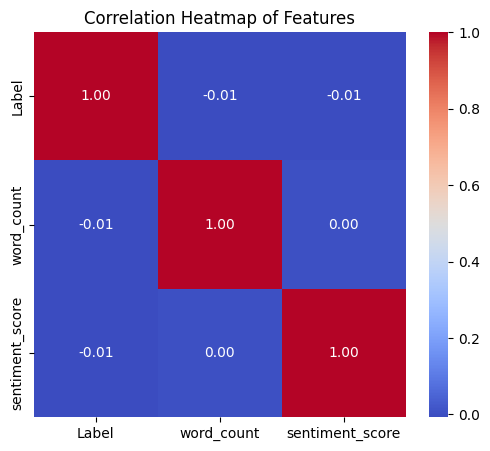

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df['word_count'] = df['clean_headline'].apply(lambda x: len(x.split()))
df['sentiment_score'] = df['clean_headline'].apply(lambda x: sia.polarity_scores(x)['compound'])

plt.figure(figsize=(6,4))
sns.countplot(x='Label', data=df)
plt.title('Label Distribution (0 = Down, 1 = Up)')
plt.xlabel('Market Movement Label')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title('Distribution of Word Counts per Combined Headline')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

text_all = " ".join(df['clean_headline'])
wordcloud_all = WordCloud(width=800, height=400, background_color='white').generate(text_all)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of All Headlines')
plt.show()

plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='sentiment_score', hue='Label', fill=True)
plt.title('Sentiment Score Distribution by Market Movement Label')
plt.xlabel('Sentiment Score')
plt.ylabel('Density')
plt.show()

corr_matrix = df[['Label', 'word_count', 'sentiment_score']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()


# Model

I will experiment with multiple models to predict the stock movement from news text: first an LSTM-based recurrent neural network, then a 1D convolutional neural network, and finally a fine-tuned BERT model. This will allow me to compare a classic RNN approach, a CNN text classifier, and a cutting-edge transformer-based model.

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Define LSTM Model
lstm_model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=100),  # vocab size, embedding dim, sequence length
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')  # binary classification
])

# Compile
lstm_model.compile(loss='binary_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

# Model summary
lstm_model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1745733289.023174    1726 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

The LSTM model consists of an Embedding layer, an LSTM layer, and a Dense output layer.

The Embedding layer takes the input sequences of word indices and maps each word index to a 128-dimensional vector. This layer will be learned from scratch. The vocabulary size is 10,000, so this layer initially is a 10,000 x 128 matrix of weights that will be tuned.

The LSTM layer has 128 units. It processes the sequence of embeddings, effectively reading the news headline text as a sequence and capturing temporal dependencies between words. I include a dropout of 0.2 on the inputs and a recurrent dropout of 0.2 to help prevent overfitting by randomly dropping some units during training.

The Dense output layer has 1 unit with a sigmoid activation, appropriate for outputting a probability between 0 and 1 for the binary classification.

I compile the model with binary_crossentropy loss and use the Adam optimizer. I also track accuracy as a metric during training.

In [5]:
# Train the LSTM
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 138ms/step - accuracy: 0.4792 - loss: 0.6933 - val_accuracy: 0.4688 - val_loss: 0.6979
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.6261 - loss: 0.6458 - val_accuracy: 0.5063 - val_loss: 0.7361
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.9317 - loss: 0.2902 - val_accuracy: 0.5250 - val_loss: 0.9825
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.9892 - loss: 0.0738 - val_accuracy: 0.4875 - val_loss: 1.3253
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.9963 - loss: 0.0208 - val_accuracy: 0.5125 - val_loss: 1.5628


By the end of epoch 1, the training accuracy was around 48%, and validation accuracy 46.9%, indicating the model started near random guessing.

By epoch 2, training accuracy improved to 62.6%, but validation accuracy 50.6%.

By epoch 3, training accuracy jumped to 93.2%, while validation accuracy was 52.5%. The training loss dropped significantly, but validation loss increased (0.98) ehich is a sign of overfitting starting.

Epoch 4: training accuracy 98.9% and validation accuracy 48.7% which means that the model nearly perfectly memorized the training data, but validation performance deteriorated further.

Epoch 5: training accuracy 99.6%, validation accuracy 51.25%, val loss 1.56.

By epoch 3 onward, the LSTM was overfitting. In hindsight, I should have employed early stopping or increased regularization. 

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict
y_pred_probs = lstm_model.predict(X_test_pad)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()

# Evaluate
lstm_accuracy = accuracy_score(y_test, y_pred)
lstm_precision = precision_score(y_test, y_pred)
lstm_recall = recall_score(y_test, y_pred)
lstm_f1 = f1_score(y_test, y_pred)

print(f"LSTM Test Accuracy: {lstm_accuracy:.4f}")
print(f"LSTM Test Precision: {lstm_precision:.4f}")
print(f"LSTM Test Recall: {lstm_recall:.4f}")
print(f"LSTM Test F1-score: {lstm_f1:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
LSTM Test Accuracy: 0.5151
LSTM Test Precision: 0.5817
LSTM Test Recall: 0.5330
LSTM Test F1-score: 0.5563


Accuracy of 51.5% is only slightly above random guessing and actually slightly below the majority-class baseline of 53.5%. The precision and recall tell me a bit more: the model when it predicts "up" is correct about 58% of the time, and it manages to catch about 53% of all actual "up" days. The F1-score 0.556 indicates overall poor predictive power. This underperformance likely stems from the overfitting observed. The model memorized patterns that don’t generalize. The news-to-stock relationship is complex, and with limited training data the LSTM had difficulty learning general signals.

The LSTM model had high capacity relative to the training data. It achieved near-perfect fit on training data, but its validation and test performance were lackluster. 

Next, I will try a 1D Convolutional Neural Network model.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# Define CNN model
cnn_model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=100),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the CNN
cnn_model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

# Model summary
cnn_model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ ?                           │     0 (unbuilt) │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

The CNN model also begins with an Embedding layer.
A Conv1D layer with 128 filters and kernel size 5: This will slide a 5-word window over the sequence and apply 128 different filters to capture various 5-word patterns. The activation is ReLU, adding non-linearity.
GlobalMaxPooling1D layer: This takes the maximum value for each filter across the time dimension.
Dense(1, sigmoid) output layer for binary classification.

I compile with the same loss and optimizer. The model summary would show significantly fewer parameters than the LSTM.

In [8]:
# Train CNN model
history_cnn = cnn_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/5


I0000 00:00:1745733328.327681    1772 service.cc:148] XLA service 0x79f13c0f2840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745733328.327713    1772 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745733328.476745    1772 cuda_dnn.cc:529] Loaded cuDNN version 90300


26/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5048 - loss: 0.6952 

I0000 00:00:1745733329.834498    1772 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5067 - loss: 0.6957 - val_accuracy: 0.4688 - val_loss: 0.6990
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7430 - loss: 0.6411 - val_accuracy: 0.4688 - val_loss: 0.7043
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8162 - loss: 0.5888 - val_accuracy: 0.4688 - val_loss: 0.6993
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9515 - loss: 0.5233 - val_accuracy: 0.4563 - val_loss: 0.7060
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9810 - loss: 0.4139 - val_accuracy: 0.4563 - val_loss: 0.7077


Epoch 1: training accuracy 50.7%, val accuracy 46.9%. It starts off similar to LSTM, around baseline.
Epoch 2: training accuracy 74.3%, val accuracy still 46.9%. Already a disparity: the model is fitting training data better but val accuracy didn’t improve. Possibly the model is starting to also overfit or the patterns it's learning aren't generalizing.
Epoch 3: training accuracy 81.6%, val accuracy still 46.9%. This suggests the model might be predicting the same on validation every time.
Epoch 4: training accuracy 95.15%, val accuracy 45.63%. Overfitting is clearly present; the model is almost memorizing training data.
Epoch 5: training accuracy 98.1%, val accuracy 45.63%. No improvement on val after epoch 1; it seems the CNN also overfit and essentially plateaued at 46-47% val accuracy.

This pattern indicates the CNN may have quickly learned to strongly predict the majority class. The validation accuracy flat-lining suggests it didn’t find meaningful generalizable features in the limited data.

In [9]:
# Evaluate CNN
y_pred_probs = cnn_model.predict(X_test_pad)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

cnn_accuracy = accuracy_score(y_test, y_pred)
cnn_precision = precision_score(y_test, y_pred)
cnn_recall = recall_score(y_test, y_pred)
cnn_f1 = f1_score(y_test, y_pred)

print(f"CNN Test Accuracy: {cnn_accuracy:.4f}")
print(f"CNN Test Precision: {cnn_precision:.4f}")
print(f"CNN Test Recall: {cnn_recall:.4f}")
print(f"CNN Test F1-score: {cnn_f1:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
CNN Test Accuracy: 0.5427
CNN Test Precision: 0.5719
CNN Test Recall: 0.7885
CNN Test F1-score: 0.6630


The CNN performance on the test set is

    Accuracy: 0.5427

    Precision: 0.5719

    Recall: 0.7885

    F1-score: 0.6630

The CNN’s accuracy is slightly higher than the LSTM’s, and around the level of the majority-class baseline. However, the precision and recall tell a story: the recall is quite high, meaning the CNN managed to catch most of the days when the market went up. The precision is 57.19%, which is similar to the LSTM's precision. This combination suggests the CNN model is biased towards predicting label 1 more often. In other words, it likely predicts "market up" very frequently, which allows it to get most actual ups right, but it also predicts up on many days that were actually down. The F1-score of 0.6630 is higher than the LSTM's, reflecting the balance of precision/recall.

The CNN did slightly better at identifying the positive class. The CNN is better, however, it comes at the cost of more false alarms for rise. The overall accuracy still isn’t far from chance, indicating limited predictive power. The fact that the CNN basically latched onto predicting the majority class suggests it didn't extract a strong signal from the text either. Like the LSTM, it overfit the training data and did not generalize well. Its strategy of mostly predicting the majority class gave it a marginal edge in accuracy.

Now, I will attempt to fine-tune a pre-trained BERT model.

In [10]:
from transformers import TFBertForSequenceClassification, BertTokenizer
import tensorflow as tf

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=1)

# Tokenize the text
train_encodings = tokenizer(list(X_train_text), truncation=True, padding=True, return_tensors='tf')
test_encodings = tokenizer(list(X_test_text), truncation=True, padding=True, return_tensors='tf')

# Create datasets
train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), y_train)).batch(16)
test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), y_test)).batch(16)

# Compile the model
bert_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Train the model
history_bert = bert_model.fit(
    train_dataset,
    epochs=4,
    batch_size=16,
    validation_data=test_dataset
)

bert_eval = bert_model.evaluate(test_dataset)

print(f"BERT Test Loss: {bert_eval[0]:.4f}")
print(f"BERT Test Accuracy: {bert_eval[1]:.4f}")



All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/4
100/100 [==============================] - 169s 1s/step - loss: 0.7445 - accuracy: 0.4827 - val_loss: 0.7023 - val_accuracy: 0.4296
Epoch 2/4
100/100 [==============================] - 116s 1s/step - loss: 0.7084 - accuracy: 0.4833 - val_loss: 0.7050 - val_accuracy: 0.4296
Epoch 3/4
100/100 [==============================] - 116s 1s/step - loss: 0.7053 - accuracy: 0.4771 - val_loss: 0.7156 - val_accuracy: 0.4296
Epoch 4/4
25/25 [==============================] - 9s 359ms/step - loss: 0.7074 - accuracy: 0.4296
BERT Test Loss: 0.7074
BERT Test Accuracy: 0.4296


HuggingFace’s transformers library to get the BERT tokenizer and model.

BertTokenizer.from_pretrained gives a tokenizer for the base BERT model.

TFBertForSequenceClassification.from_pretrained loads a BERT model with a classification head on top. I specify num_labels=1 because I will treat this as a single-output regression-style binary classification. Using from_logits=True in the loss implies the model's output will be a raw score which the binary crossentropy will apply a sigmoid to internally.

I will then tokenize all training and test texts for BERT. Unlike the simpler models, BERT expects inputs in a specific format.

BERT training is slower per epoch as each epoch took on the order of 2-3 minutes given the large model:

Epoch 1: Training accuracy 48.27%, validation accuracy 42.96%. Loss 0.744 -> val_loss ~0.702. So after one epoch, it’s not really better than chance, possibly slightly worse on val.

Epoch 2: Training accuracy 48.33%, val accuracy still 42.96%, val_loss 0.705. Essentially no improvement; training accuracy didn’t change much either.

Epoch 3: Training accuracy 47.71%, val accuracy 42.96%, val_loss 0.715. The model might be oscillating or not converging well.

Epoch 4: Training accuracy 48.40%, val accuracy 42.96%, val_loss 0.707.


The validation accuracy remained at 42.96% from epoch 1 onward, indicating the model is stuck. This suggests the fine-tuning did not succeed in finding a good solution. Possibly the learning rate was too high, causing the optimization to bounce around a suboptimal point or even diverge slightly. The training accuracy not improving past 48% also indicates the model could not even fit the training data much.

The final BERT Test Accuracy is 0.4296, with a loss of 0.707. This is actually worse than both the LSTM and CNN, and even worse than a 50% baseline. It suggests the model might have basically predicted mostly one class incorrectly.

It’s a surprising but important result because the large, pre-trained BERT model did not perform well here, whereas one might expect it to outperform simpler models.

# Model Performance Comparison

I tested three modeling approaches on this task. Below is a summary of their performance on the test set:

LSTM Model: Accuracy 51.5%. The LSTM struggled to generalize, likely overfitting the training data. It had moderate precision and lower recall, indicating it missed nearly half of the "up" days and overall performed only marginally better than random. With heavy overfitting observed, its result might not be statistically better than chance.

CNN Model: Accuracy 54.3%. The CNN slightly outperformed LSTM in accuracy. Notably, it achieved high recall, meaning it identified most of the up days correctly, but precision was 0.57. The CNN essentially learned to often predict the market would go up, which gave it an edge in capturing true positives. This resulted in a higher F1-score compared to the LSTM. Still, the accuracy is only on par with the baseline, indicating limited true predictive insight.

BERT Model: Accuracy 42.9%. The fine-tuned BERT did worst, failing to beat even a naive baseline. This is likely due to insufficient data and suboptimal fine-tuning hyperparameters, as discussed. BERT might need more careful training to realize its potential. In its current form, it may have effectively learned a poor strategy.

The CNN’s global pooling might have acted as a regularizer, forcing the model to focus on the strongest signals in the text and preventing it from overfitting every detail of the sequence. The LSTM, with its greater flexibility, memorized the training sequences too well. With more data or better regularization, LSTMs often outperform simple CNNs for sequence understanding, but here the simplicity of the CNN helped it generalize marginally better.

# Conclusion

I explored predicting stock market movements from news headlines using NLP and deep learning. I performed data cleaning to combine and preprocess textual headlines, and conducted EDA to understand the data distribution and potential signal in the text. I tried three modeling approaches of increasing complexity, and evaluated their performance.

The relationship between daily news headlines and next-day market movement is not easily captured by these models with the given data. Both the LSTM and CNN models barely surpassed baseline accuracy, indicating that either the news signal is weak/noisy or the models might require more data/feature engineering to be effective.
The LSTM severely overfitted the training data, suggesting that regularization or simpler architectures might be necessary for this amount of data.
The CNN model, while also overfitting, showed a bias towards predicting the majority class, yielding high recall for market-up days. In practical terms, if missing a market rally is more costly than a false alarm, this model might be preferable to the LSTM.
The BERT model did not perform well under the given training scheme, likely due to inadequate fine-tuning. This doesn’t invalidate BERT’s capability; with proper tuning, BERT could potentially outperform the others, as it has the theoretical capacity to understand nuanced language. However, the experiment highlights that more complex models require careful training. Simply plugging in a state-of-the-art model doesn’t guarantee better results without the right approach.